# Dans le premier pipeline, je commence par analyser le dataset, puis j’applique le prétraitement nécessaire, et enfin j’entraîne un modèle SVM pour réaliser l’analyse des sentiments.

In [1]:
import pandas as pd
import regex as re

## Data Loading

In [2]:
raw = pd.read_csv("../IMDB Dataset.csv")

In [3]:
raw

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


On constate qu'il n'y a aucune valeur manquante, et la repartition des sentiments sont 50% positive et 50% negative. Mais aussi on a 50 mille row, et 49582 unique, ce qui veut dire qu'il y a des doublants, on les élimine.

In [4]:
raw = raw.drop_duplicates(subset='review', keep='first')

In [5]:
raw

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
raw.iloc[0,0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

On peut constater dès la première ligne, qu'il y a des bradckets HTML qu'on doit enlever avec REGEX

## Prétraitement

On enlève tout d'abord les tags HTML, et pour rester structurer je crée une nouvelle dataset, cleaning.

In [7]:
cleaning = raw.copy()

In [8]:
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"<.*?>", "", x))

In [9]:
cleaning["review"][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes where other shows wo

Rend tout les lettre miniscule:

In [10]:
cleaning["review"] = cleaning["review"].apply(lambda x: x.lower())

In [11]:
cleaning["review"][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

Maintenant on fait la "Expand contractions". <br>
C'est quoi ? <br>
Par exemple on a des cas où on écrit "doesn't" à la place de "does not", et si on enlève l'apostrophe on aurait "doesn t", ce qui ensuite vas être tokeniser et ça perdera son sens. <br>
Alors quand on applique l'expansion "doesn't" devient "does not".

In [12]:
import contractions
cleaning["review"] = cleaning["review"].apply(lambda x: contractions.fix(x))

In [13]:
cleaning["review"][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. them city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other show

Maintenant la ponctuation, on enlève toute ponctuation et on le remoplace par un espace pour éviter de coller 2 mots. et aprés on enlève les espaces en exés.

In [14]:
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"[^\w\s]", " ", x))
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

In [15]:
cleaning["review"][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode you will be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda them city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows would not dare forget p

maintenant on fait la tokenisation, car les étapes antécédent le requis

In [16]:
cleaning["tokens"] = cleaning["review"].apply(lambda x: x.split())
cleaning

,review,sentiment,tokens
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter mattei s love in the time of money is a...,positive,"[petter, mattei, s, love, in, the, time, of, m..."
...,...,...,...
49995,i thought this movie did a down right good job...,positive,"[i, thought, this, movie, did, a, down, right,..."
49996,bad plot bad dialogue bad acting idiotic direc...,negative,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,i am a catholic taught in parochial elementary...,negative,"[i, am, a, catholic, taught, in, parochial, el..."
49998,i am going to have to disagree with the previo...,negative,"[i, am, going, to, have, to, disagree, with, t..."


Pour minimiser le vocabulaire pas necessaire, on enlève aussi les STOPWORDS

In [18]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

STOPWORDS = set(stopwords.words('english'))
cleaning['tokens'] = cleaning['tokens'].apply(lambda x: [token for token in x if token not in STOPWORDS])

[nltk_data] Downloading package stopwords to /home/abood/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
cleaning

,review,sentiment,tokens
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter mattei s love in the time of money is a...,positive,"[petter, mattei, love, time, money, visually, ..."
...,...,...,...
49995,i thought this movie did a down right good job...,positive,"[thought, movie, right, good, job, creative, o..."
49996,bad plot bad dialogue bad acting idiotic direc...,negative,"[bad, plot, bad, dialogue, bad, acting, idioti..."
49997,i am a catholic taught in parochial elementary...,negative,"[catholic, taught, parochial, elementary, scho..."
49998,i am going to have to disagree with the previo...,negative,"[going, disagree, previous, comment, side, mal..."


Maintenant Lemmatization pour plus minimiser le vocabulaire

In [20]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
cleaning["final"] = cleaning['tokens'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x]))

[nltk_data] Downloading package wordnet to /home/abood/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [21]:
cleaning["final"]

0        one reviewer mentioned watching 1 oz episode h...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically family little boy jake think zombie ...
4        petter mattei love time money visually stunnin...
                               ...                        
49995    thought movie right good job creative original...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    going disagree previous comment side maltin on...
49999    one expects star trek movie high art fan expec...
Name: final, Length: 49582, dtype: object

Avant de passer à l'étape prochaine, on crée la column label qui est binaire, True si review positive, False sinon.

In [22]:
cleaning["label"] = cleaning["sentiment"] == "positive"

In [23]:
cleaned = cleaning[["final", "label"]].copy()
cleaned

,final,label
0,one reviewer mentioned watching 1 oz episode h...,True
1,wonderful little production filming technique ...,True
2,thought wonderful way spend time hot summer we...,True
3,basically family little boy jake think zombie ...,False
4,petter mattei love time money visually stunnin...,True
...,...,...
49995,thought movie right good job creative original...,True
49996,bad plot bad dialogue bad acting idiotic direc...,False
49997,catholic taught parochial elementary school nu...,False
49998,going disagree previous comment side maltin on...,False


# Vectorisation

Premièrement on applique le BoW

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(min_df=3) # On ignore les mots rares, on prend juste qui apparait plus que 3 fois
bow_matrix = vectorizer.fit_transform(cleaned['final'])

In [25]:
print(bow_matrix.shape)
print(vectorizer.get_feature_names_out()[100:120])  # 20 words

(49582, 42123)
['158' '15pm' '15th' '16' '160' '1600' '161' '162' '163' '165' '168'
 '1690' '1692' '16mm' '16th' '16ème' '17' '170' '1700' '175']


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(bow_matrix, cleaned['label'], test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear', verbose=True)
svm_model.fit(X_train, y_train)

[LibSVM].....................................................................................................................................................................................................................................................................................................................*.......................................................................................................................................................*..........*
optimization finished, #iter = 469505
obj = -827.997459, rho = 0.025266
nSV = 10675, nBSV = 139
Total nSV = 10675


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,True


model took 1h 36 minutes

In [27]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = svm_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed metrics
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8567106988000404

Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.85      0.86      4939
        True       0.86      0.86      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



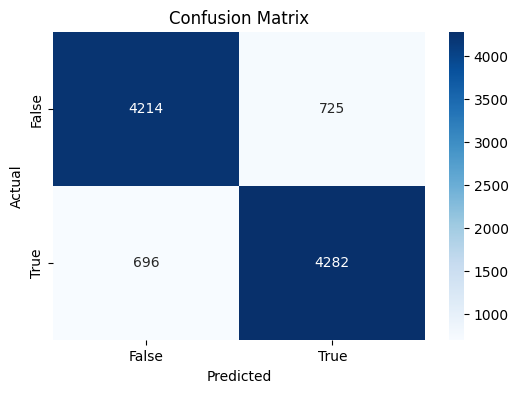

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(cleaned['label'].unique()),
            yticklabels=sorted(cleaned['label'].unique()))

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
import joblib

# Save model
joblib.dump(svm_model, "../svm_bow_model.pkl")

# Save the CountVectorizer too (needed for new predictions)
joblib.dump(vectorizer, "../countvectorizer.pkl")

['countvectorizer.pkl']

In [29]:
# For futur use
# Load model and vectorizer
svm_model = joblib.load("../svm_bow_model.pkl")
vectorizer = joblib.load("../countvectorizer.pkl")

# Example prediction
new_text = ["I love this movie"]
new_bow = vectorizer.transform(new_text)
pred = svm_model.predict(new_bow)
print(pred)
